# Detecting Outliers in Hi-C Data
While UOT can handle differences in total counts, if datasets have a large discrepancy in mass, the cost between the two datasets will still be quite large. Thus, datasets with a clearly much higher total mass than other should be removed prior to analysis as to not affect the final results. Here, we'll examine the total mass of all cells in both the immune cell data and the cell line data to see how many outliers there are and what threshold we can set.

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [39]:
### Directories and Files ###
root = '../../'
metadata_dir_immune = f"{root}Data/sc_data/cell_types.tsv"
metadata_dir_lines = f"{root}Generated Data/Single-to-single/sc_uot_ramani/Metadata/1mb_maxnorm_total_mass.csv"
data_dir_immune = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data' # Importing was not working with relative root+'..' approach, so replace with local data
data_dir_lines = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = f"{root}Generated Data/Single-to-single/outliers"

In [3]:
### Imports ###
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, get_cool_name

In [4]:
### Loading Coolers ###
clrs_immune = import_cool_dir(data_dir_immune)
clrs_lines = import_cool_dir(data_dir_lines)

names_immune = []
names_lines = []

for clr in clrs_immune:
    names_immune.append(get_cool_name(clr))

for clr in clrs_lines:
    names_lines.append(get_cool_name(clr))

In [5]:
### Loading Metadata ###
metadata_immune = pd.read_csv(metadata_dir_immune, sep="\t")
metadata_lines = pd.read_csv(metadata_dir_lines, index_col=0)

## Helper Functions

In [6]:
def add_cell_counts(ax, data: pd.DataFrame, mass_col: str, type_col: str="cell_type") -> None:
    '''
        Adds cell count information to violin plots.

        Parameters
        ----------
        ax
            Axis to add counts to.
        data : pd.DataFrame
            Dataframe containing mass information.
        mass_col : str
            Column containing mass information.
        type_col : str
            Column containing category information.
            Default = "cell_type"
    '''
    # Add cell count annotations
    counts = data[type_col].value_counts()


    # Y position above max mass
    y_max = data.groupby(type_col)[mass_col].max()

        # Adding extra space to prevent overlap with title
    y_min, y_max_plot = ax.get_ylim()
    ax.set_ylim(y_min, y_max_plot * 1.05)

    for i, cell_type in enumerate(ax.get_xticklabels()):
        ct = cell_type.get_text()
        ax.text(
            i,
            y_max[ct] * 1.03,
            f"n = {counts[ct]}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontstyle='italic'
        )
    return

## Fetching Masses

In [7]:
### Total + Chr1, Immune ###
totals_immune = []
chr1_immune = []

for clr in clrs_immune:
    # Total
    totals_immune.append(clr.info["sum"])

    # Chr1
    low, high = clr.extent("chr1")
    chr1_total = clr.matrix(balance=False)[low:high, low:high].sum()
    chr1_immune.append(chr1_total)

In [8]:
### Total + Chr1, Lines ###
totals_lines = []
chr1_lines = []

for clr in clrs_lines:
    # Total
    totals_lines.append(clr.info["sum"])

    # Chr1
    low, high = clr.extent("chr1")
    chr1_total = clr.matrix(balance=False)[low:high, low:high].sum()
    chr1_lines.append(chr1_total)

In [25]:
### Converting to dfs ###
masses_immune = pd.DataFrame({
    "cell_name" : names_immune,
    "total_mass" : totals_immune,
    "chr1_mass" : chr1_immune
})
masses_immune = masses_immune.merge(metadata_immune, on="cell_name")

masses_lines = pd.DataFrame({
    "cell_name" : names_lines,
    "total_mass" : totals_lines,
    "chr1_mass" : chr1_lines
})
masses_lines = masses_lines.merge(metadata_lines[["cell_name", "cell_line"]], on="cell_name")

## Visualizing

### Histograms

Text(0, 0.5, 'Count')

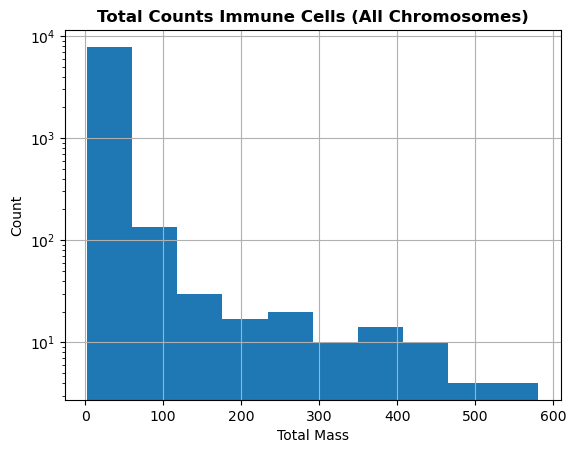

In [10]:
### Immune Cells, Total ###
masses_immune["total_mass"].hist()

plt.yscale('log')
plt.title("Total Counts Immune Cells (All Chromosomes)", fontweight="bold")
plt.xlabel("Total Mass")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

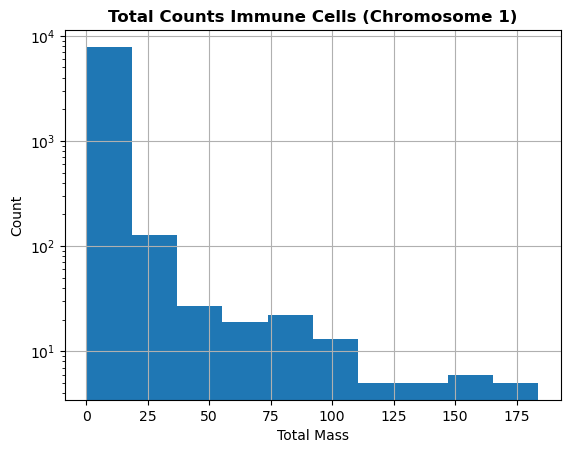

In [11]:
### Immune Cells, Chr1 ###
masses_immune["chr1_mass"].hist()

plt.yscale('log')
plt.title("Total Counts Immune Cells (Chromosome 1)", fontweight="bold")
plt.xlabel("Total Mass")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

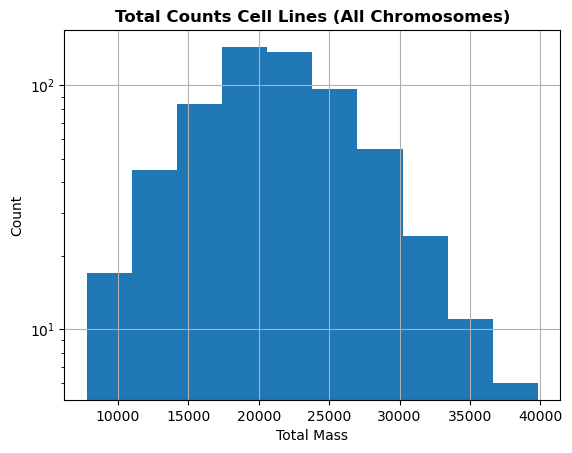

In [12]:
### Lines Cells, Total ###
masses_lines["total_mass"].hist()

plt.yscale('log')
plt.title("Total Counts Cell Lines (All Chromosomes)", fontweight="bold")
plt.xlabel("Total Mass")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

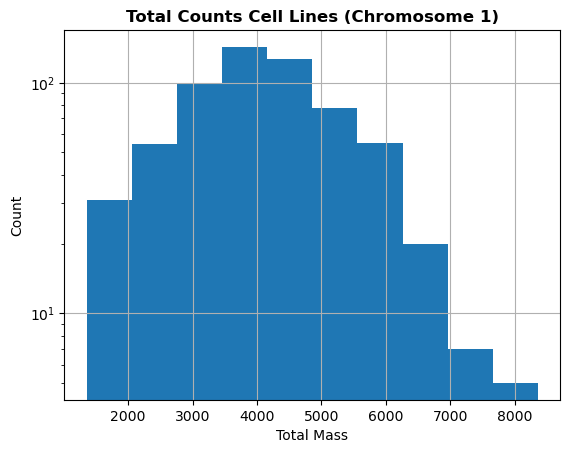

In [13]:
### Lines Cells, Chr1 ###
masses_lines["chr1_mass"].hist()

plt.yscale('log')
plt.title("Total Counts Cell Lines (Chromosome 1)", fontweight="bold")
plt.xlabel("Total Mass")
plt.ylabel("Count")

### Violin Plots, Combined

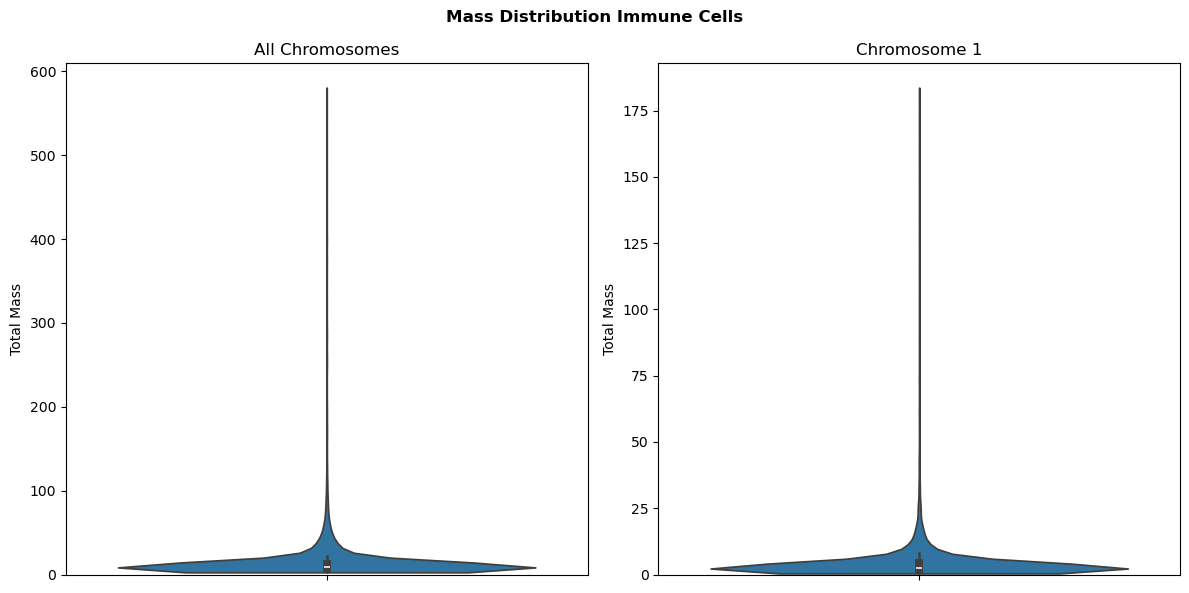

In [14]:
### Immune Cells ###
fig, ax = plt.subplots(1, 2, figsize=(12,6))

    # Totals
sns.violinplot(masses_immune["total_mass"], ax=ax[0], cut=0)
ax[0].set_ylabel("Total Mass")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")

    # Chr1
sns.violinplot(masses_immune["chr1_mass"], ax=ax[1], cut=0)
ax[1].set_ylabel("Total Mass")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")

    # General Formatting
plt.suptitle("Mass Distribution Immune Cells", fontweight='bold')
plt.tight_layout()

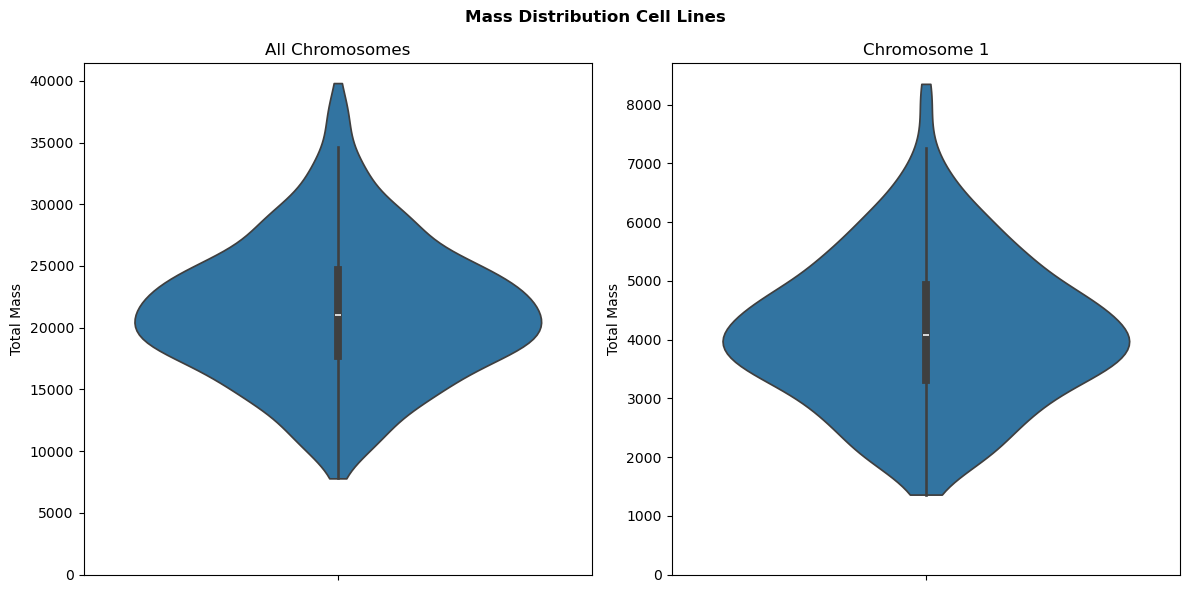

In [15]:
### Cell Lines ###
fig, ax = plt.subplots(1, 2, figsize=(12,6))

    # Totals
sns.violinplot(masses_lines["total_mass"], ax=ax[0], cut=0)
ax[0].set_ylabel("Total Mass")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")

    # Chr1
sns.violinplot(masses_lines["chr1_mass"], ax=ax[1], cut=0)
ax[1].set_ylabel("Total Mass")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")

    # General Formatting
plt.suptitle("Mass Distribution Cell Lines", fontweight='bold')
plt.tight_layout()

### Violin plots, Categorized

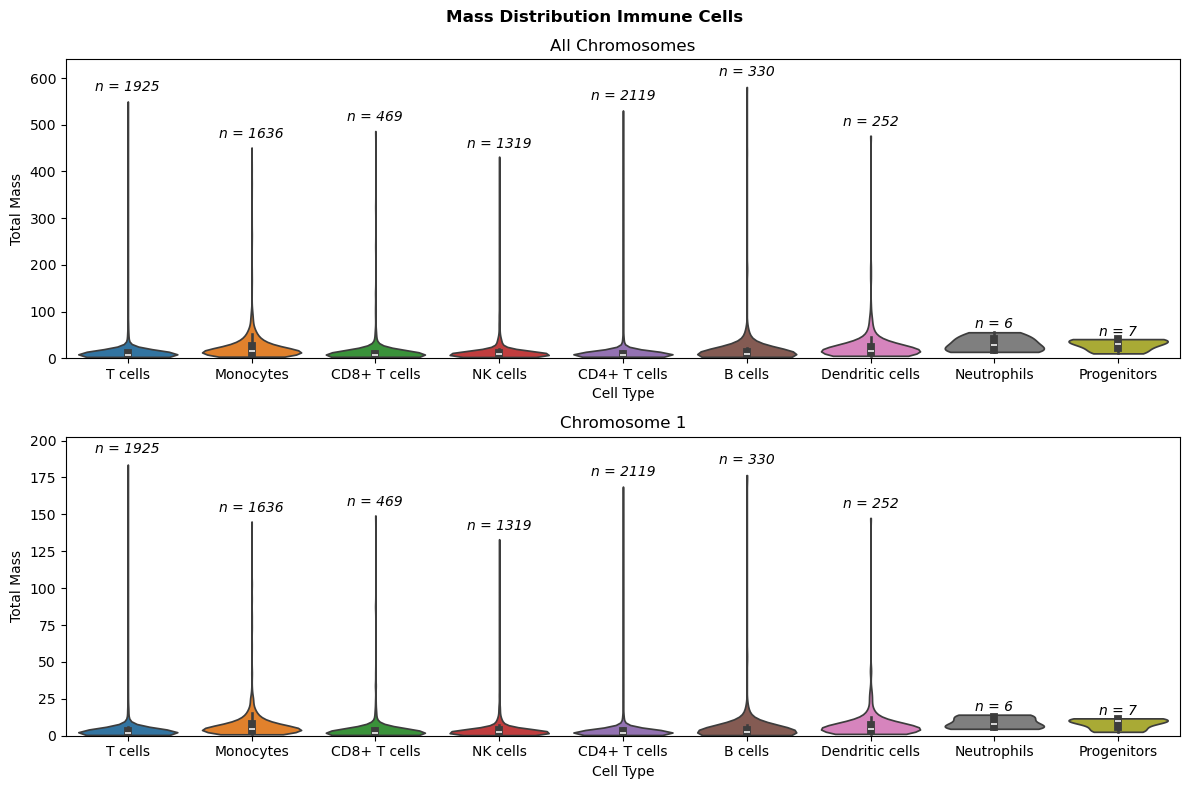

In [16]:
### Immune Cells ###
fig, ax = plt.subplots(2, 1, figsize=(12,8))

    # Totals
sns.violinplot(
    data = masses_immune, 
    ax=ax[0],
    x="cell_type",
    y="total_mass",
    hue="cell_type",
    cut=0
    )
ax[0].set_ylabel("Total Mass")
ax[0].set_xlabel("Cell Type")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")
add_cell_counts(ax[0], masses_immune, "total_mass")

    # Chr1
sns.violinplot(
    data = masses_immune, 
    ax=ax[1],
    x="cell_type",
    y="chr1_mass",
    hue="cell_type",
    cut=0
    )
ax[1].set_ylabel("Total Mass")
ax[1].set_xlabel("Cell Type")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")
add_cell_counts(ax[1], masses_immune, "chr1_mass")

    # General Formatting
plt.suptitle("Mass Distribution Immune Cells", fontweight='bold')
plt.tight_layout()

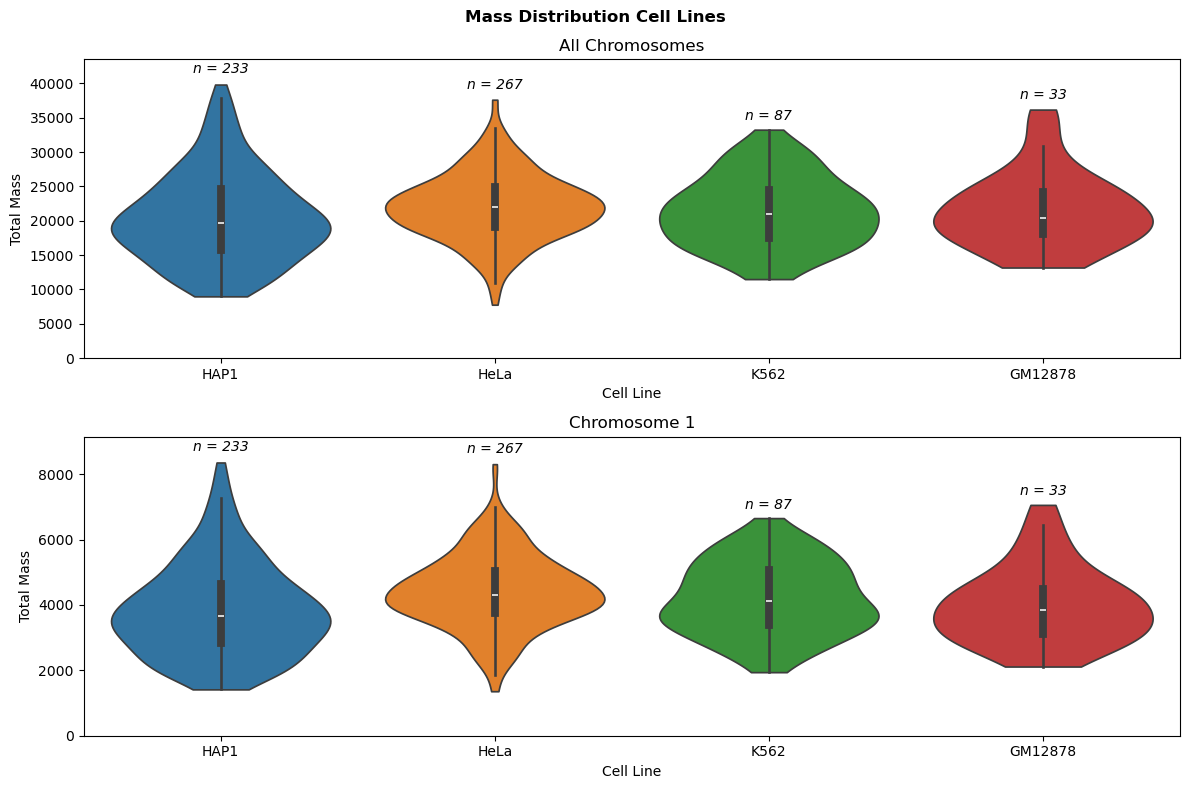

In [17]:
### Cell Lines ###
fig, ax = plt.subplots(2, 1, figsize=(12,8))

    # Totals
sns.violinplot(
    data = masses_lines, 
    ax=ax[0],
    x="cell_line",
    y="total_mass",
    hue="cell_line",
    cut=0
    )
ax[0].set_ylabel("Total Mass")
ax[0].set_xlabel("Cell Line")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")
add_cell_counts(ax[0], masses_lines, "total_mass", "cell_line")

    # Chr1
sns.violinplot(
    data = masses_lines, 
    ax=ax[1],
    x="cell_line",
    y="chr1_mass",
    hue="cell_line",
    cut=0
    )
ax[1].set_ylabel("Total Mass")
ax[1].set_xlabel("Cell Line")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")
add_cell_counts(ax[1], masses_lines, "chr1_mass", "cell_line")

    # General Formatting
plt.suptitle("Mass Distribution Cell Lines", fontweight='bold')
plt.tight_layout()

It seems that the cell line dataset barely includes any outliers, while te immune cell dataset contains quite a few.

## Outliers

Below, we'll remove outliers using the IQR rule and visualize how the resulting distribution looks

In [31]:
### Trimming outliers, Immune ###
q1_immune = np.percentile(masses_immune["total_mass"], 25)
q3_immune = np.percentile(masses_immune["total_mass"], 75)
iqr_immune = q3_immune - q1_immune
lower_immune = q1_immune - 1.5 * iqr_immune
upper_immune = q3_immune + 1.5 * iqr_immune

masses_immune_outliers = masses_immune[
    (masses_immune["total_mass"] > upper_immune) |
    (masses_immune["total_mass"] < lower_immune)
]

masses_immune_trimmed = masses_immune[~masses_immune["cell_name"].isin(masses_immune_outliers["cell_name"])]

In [36]:
### Trimming outliers, Cell Lines ###
q1_lines = np.percentile(masses_lines["total_mass"], 25)
q3_lines = np.percentile(masses_lines["total_mass"], 75)
iqr_lines = q3_lines - q1_lines
lower_lines = q1_lines - 1.5 * iqr_lines
upper_lines = q3_lines + 1.5 * iqr_lines

masses_lines_outliers = masses_lines[
    (masses_lines["total_mass"] > upper_lines) |
    (masses_lines["total_mass"] < lower_lines)
]

masses_lines_trimmed = masses_lines[~masses_lines["cell_name"].isin(masses_lines_outliers["cell_name"])]

In [40]:
### Saving outliers ###
masses_immune_outliers.to_csv(f"{save_dir}/outliers_immune_iqr15.csv")
masses_lines_outliers.to_csv(f"{save_dir}/outliers_lines_iqr15.csv")

### Violin Plots, Combined

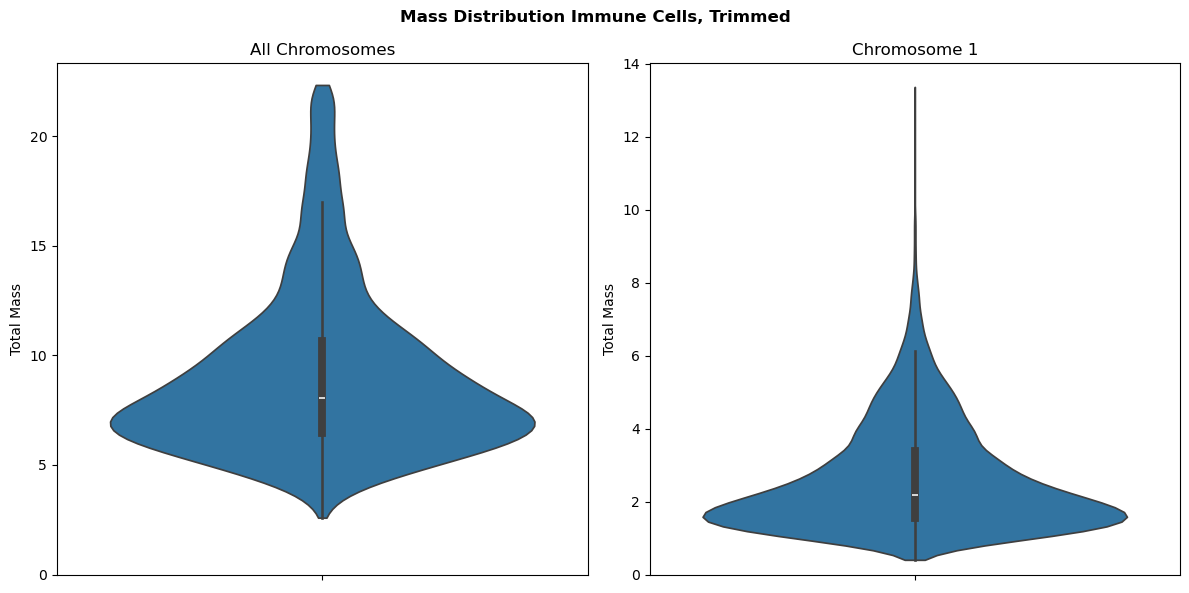

In [37]:
### Immune Cells ###
fig, ax = plt.subplots(1, 2, figsize=(12,6))

    # Totals
sns.violinplot(masses_immune_trimmed["total_mass"], ax=ax[0], cut=0)
ax[0].set_ylabel("Total Mass")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")

    # Chr1
sns.violinplot(masses_immune_trimmed["chr1_mass"], ax=ax[1], cut=0)
ax[1].set_ylabel("Total Mass")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")

    # General Formatting
plt.suptitle("Mass Distribution Immune Cells, Trimmed", fontweight='bold')
plt.tight_layout()

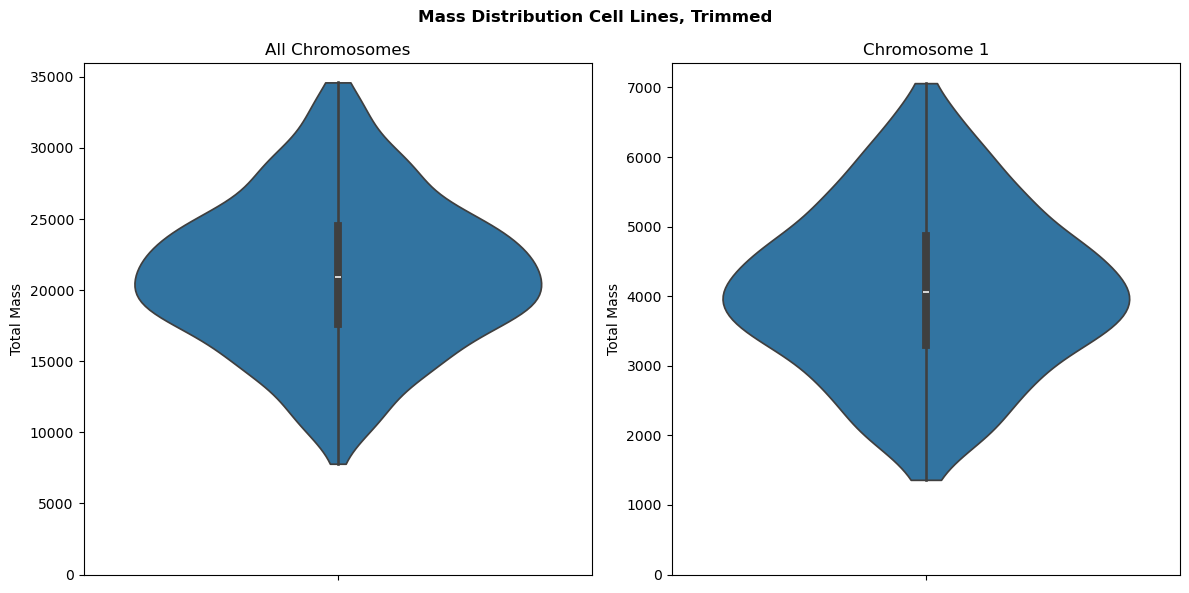

In [38]:
### Cell Lines ###
fig, ax = plt.subplots(1, 2, figsize=(12,6))

    # Totals
sns.violinplot(masses_lines_trimmed["total_mass"], ax=ax[0], cut=0)
ax[0].set_ylabel("Total Mass")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")

    # Chr1
sns.violinplot(masses_lines_trimmed["chr1_mass"], ax=ax[1], cut=0)
ax[1].set_ylabel("Total Mass")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")

    # General Formatting
plt.suptitle("Mass Distribution Cell Lines, Trimmed", fontweight='bold')
plt.tight_layout()

### Violin plots, Categorized

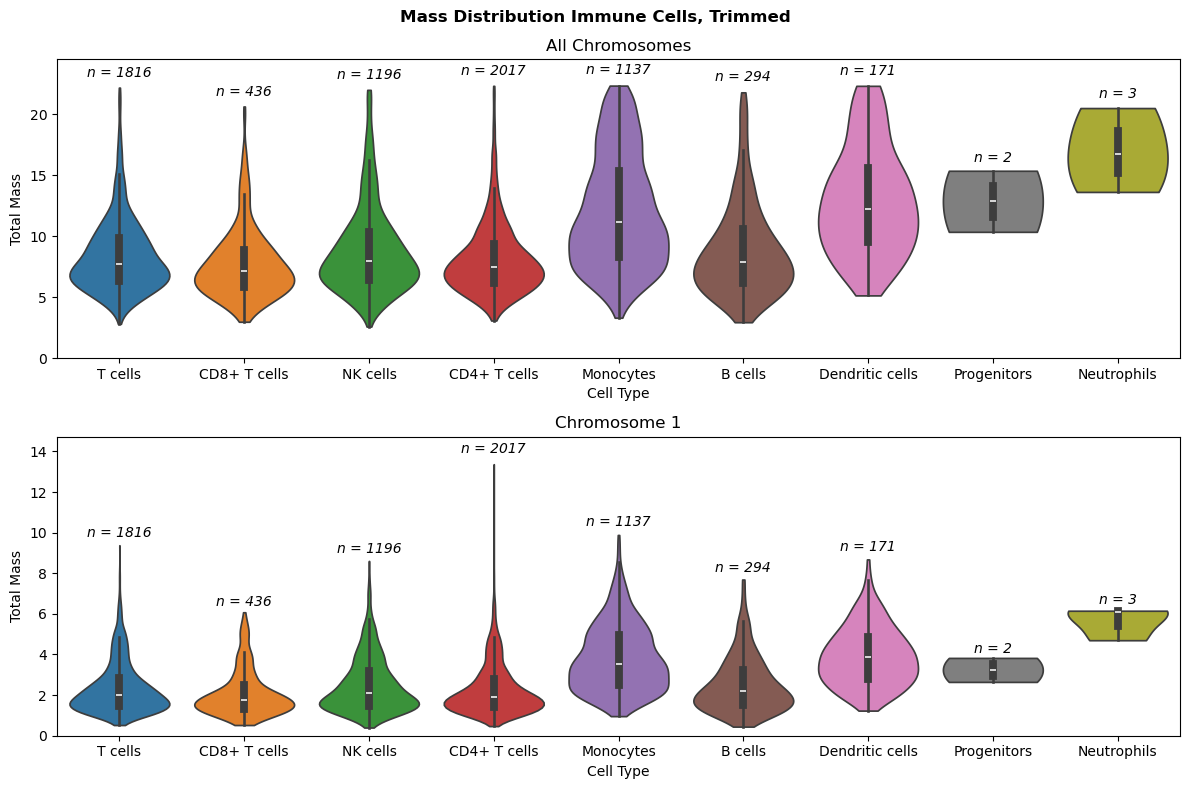

In [ ]:
### Immune Cells ###
fig, ax = plt.subplots(2, 1, figsize=(12,8))

    # Totals
sns.violinplot(
    data = masses_immune_trimmed, 
    ax=ax[0],
    x="cell_type",
    y="total_mass",
    hue="cell_type",
    cut=0
    )
ax[0].set_ylabel("Total Mass")
ax[0].set_xlabel("Cell Type")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")
add_cell_counts(ax[0], masses_immune_trimmed, "total_mass")

    # Chr1
sns.violinplot(
    data = masses_immune_trimmed, 
    ax=ax[1],
    x="cell_type",
    y="chr1_mass",
    hue="cell_type",
    cut=0
    )
ax[1].set_ylabel("Total Mass")
ax[1].set_xlabel("Cell Type")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")
add_cell_counts(ax[1], masses_immune_trimmed, "chr1_mass")

    # General Formatting
plt.suptitle("Mass Distribution Immune Cells, Trimmed", fontweight='bold')
plt.tight_layout()

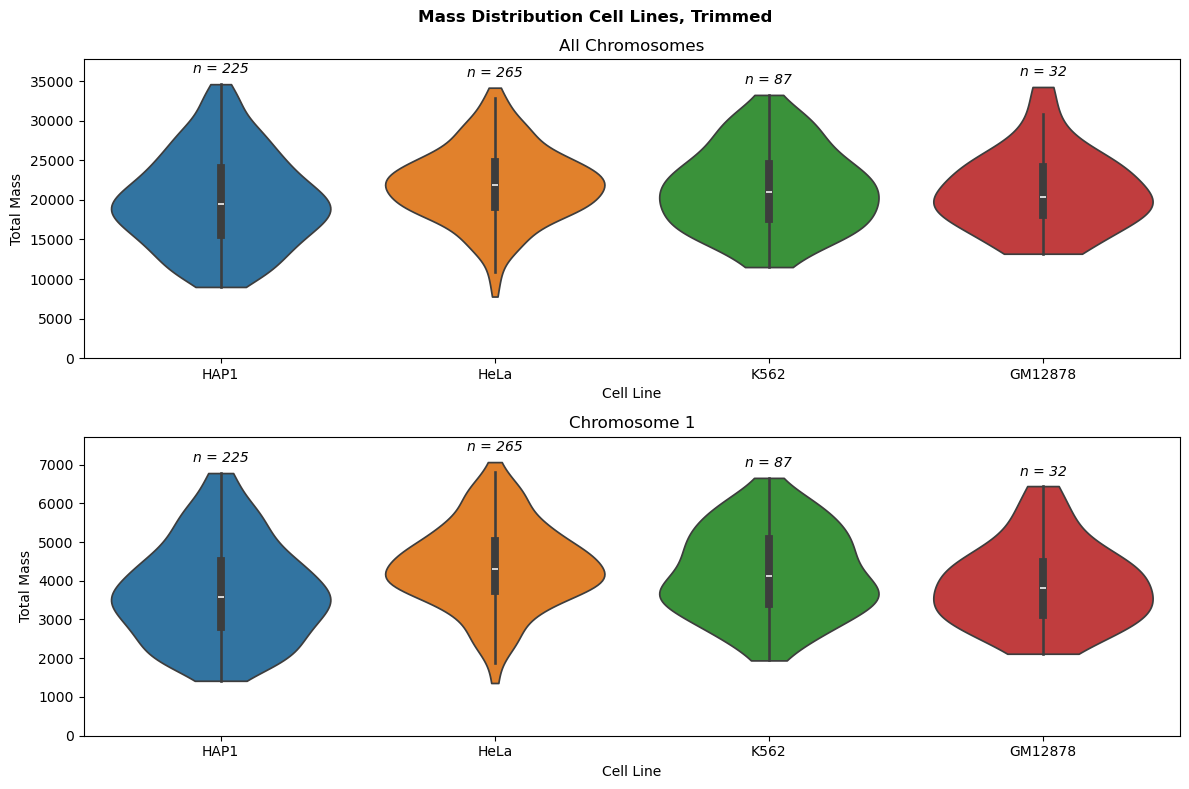

In [ ]:
### Cell Lines ###
fig, ax = plt.subplots(2, 1, figsize=(12,8))

    # Totals
sns.violinplot(
    data = masses_lines_trimmed, 
    ax=ax[0],
    x="cell_line",
    y="total_mass",
    hue="cell_line",
    cut=0
    )
ax[0].set_ylabel("Total Mass")
ax[0].set_xlabel("Cell Line")
ax[0].set_ylim(bottom=0)
ax[0].set_title("All Chromosomes")
add_cell_counts(ax[0], masses_lines_trimmed, "total_mass", "cell_line")

    # Chr1
sns.violinplot(
    data = masses_lines_trimmed, 
    ax=ax[1],
    x="cell_line",
    y="chr1_mass",
    hue="cell_line",
    cut=0
    )
ax[1].set_ylabel("Total Mass")
ax[1].set_xlabel("Cell Line")
ax[1].set_ylim(bottom=0)
ax[1].set_title("Chromosome 1")
add_cell_counts(ax[1], masses_lines_trimmed, "chr1_mass", "cell_line")

    # General Formatting
plt.suptitle("Mass Distribution Cell Lines, Trimmed", fontweight='bold')
plt.tight_layout()

Trimming does not affect the cell lines data set much. <br>
The immune cell dataset is affected much more, but seems reasonable. <br>
One major concern I have looking at the trimmed dataset is that the clustering we observe is almost exclusively determined by the difference in mass average between lymphoid and myeloid seen in the immune cell data. While the conclusion can still be biologically relevant, this could mean that UOT is not a great tool for separating cells based on architecture alone. 